# Baseline Evaluation

## Imports

In [23]:
import sys; sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from src.rolling_origin_cv import rolling_origin_cutoffs
from src.models import seasonal_naive_forecast, ets_forecast
from src.evaluate import rmsle, wape, score_table

## Load Data

In [2]:
df = pd.read_parquet("../data/processed/train.parquet")
print(f"{len(df)} rows | {df.date.min().date()} -> {df.date.max().date()}")

3000888 rows | 2013-01-01 -> 2017-08-15


In [3]:
# Sanity check for rolling_origin_cutoffs()

for c in rolling_origin_cutoffs(df.date, horizon=16, n_folds=4):
    tr = (df.date <= c).sum()
    te = ((df.date > c) & (df.date <= c + pd.Timedelta(days=16))).sum()
    print(c.date(), "train rows:", f"{tr:,}", "test rows:", f"{te:,}")
    assert df[df.date <= c].date.max() < (df[(df.date > c)].date.min()), "LEAK: train overlaps test"

2017-06-12 train rows: 2,886,840 test rows: 28,512
2017-06-28 train rows: 2,915,352 test rows: 28,512
2017-07-14 train rows: 2,943,864 test rows: 28,512
2017-07-30 train rows: 2,972,376 test rows: 28,512


## Baselines

In [9]:
def evaluate_baseline(df, forecast_fn, horizon=16, n_folds=4):
    """Run a forecast function through rolling_origin_cv and return long predictions in a dataframe."""

    cutoffs = rolling_origin_cutoffs(df.date, horizon, n_folds)
    rows = []

    for fold, cutoff in enumerate(cutoffs):
        train = df[df.date <= cutoff]
        test = df[(df.date > cutoff) & (df.date <= cutoff + pd.Timedelta(days=horizon))]

        grouped = train.groupby(["store_nbr", "family"], observed=True)
        for (store, family), g_train in tqdm(grouped, total=grouped.ngroups, desc=f"Fold {fold + 1}/{n_folds} (cutoff {cutoff.date()})", leave=True):
            s = g_train.set_index("date")["sales"].sort_index().asfreq("D").fillna(0)
            preds = forecast_fn(s, horizon)

            g_test = test[(test.store_nbr == store) & (test.family == family)].sort_values("date")
            n = min(len(g_test), horizon)

            if n == 0:
                continue
            rows.append(pd.DataFrame({
                "fold": fold, "store_nbr": store, "family": family,
                "date": g_test.date.values[:n],
                "y_true": g_test.sales.values[:n],
                "y_pred": preds[:n]
            }))
    
    return pd.concat(rows, ignore_index=True)

In [10]:
sn_preds = evaluate_baseline(df, seasonal_naive_forecast)
ets_preds = evaluate_baseline(df, ets_forecast)

sn_overall, sn_fam = score_table(sn_preds, "seasonal_naive")
ets_overall, ets_fam = score_table(ets_preds, "ets")

results = pd.concat([sn_overall, ets_overall], ignore_index=True)
print(results)

Fold 4/4 (cutoff 2017-07-30): 100%|██████████| 1782/1782 [06:11<00:00,  4.80it/s]


            model     RMSLE      WAPE
0  seasonal_naive  0.546429  0.169253
1             ets  0.450813  0.150874


In [14]:
by_family_table = pd.concat([sn_fam, ets_fam], ignore_index=True)

In [15]:
results.to_csv("../outputs/results/baseline_scores.csv", index=False)
by_family_table.to_csv("../outputs/results/baseline_scores_by_family.csv", index=False)

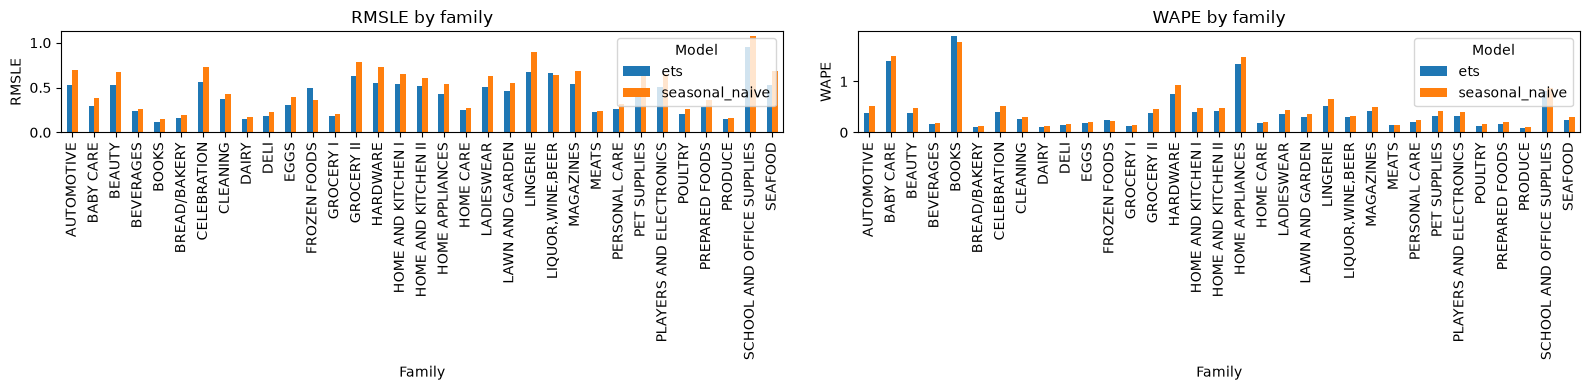

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16,4))
for ax, metric in zip(axes, ["RMSLE", "WAPE"]):
    pivot = (by_family_table).pivot(index="family", columns="model", values= metric)
    pivot.plot(kind="bar", stacked=False, ax=ax)
    ax.set_title(f"{metric} by family")
    ax.set_xlabel("Family")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=90)
    ax.legend(title="Model")

plt.tight_layout()
plt.show()